In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')


## 1: Load and Preprocess Data

In [2]:
# Load fully feature-engineered dataset
df = pd.read_csv("feature_engineering/data_with_new_features_v3.csv")
participant_col_name = 'participant'

### Select Features

In [3]:
import re

def select_feature_groups(df, group_names):
    base = ['timestamp', 'participant', 'genre']

    groups = {
        "raw": [
            'heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm',
            'iris_diameter_mm', 'pupil_iris_ratio', 'head_displacement',
            'head_velocity', 'head_direction_change_rate', 'head_stability',
            'centered_x', 'centered_y'
        ],
        "time_domain": [col for col in df.columns if col.startswith("td_")],
        "fft": [col for col in df.columns if "_fft_" in col],
        "entropy": [col for col in df.columns if "_entropy" in col],
        "stat_moments": [col for col in df.columns if any(k in col for k in ['_skew', '_kurtosis'])],
        "bucket": [col for col in df.columns if col.endswith("_bucket")],
        "bucket_transitions": [col for col in df.columns if re.match(r'.*_(low|normal|high)_(low|normal|high)$', col)],
        "nonlinear": [col for col in df.columns if "_entropy" in col or "_sample_entropy" in col or "_approx_entropy" in col],
    }

    selected = set(base)
    for name in group_names:
        selected.update(groups.get(name, []))

    return df[list(selected)]


df = select_feature_groups(df, ['raw', 'time_domain', 'fft', 'entropy', 'bucket', 'nonlinear'])

### Encoding & Scaling

In [4]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [5]:
# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference(exclude_cols)

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])


## 2. Train/Val/Test Split by Participants

In [6]:
# Split Clara for test only
test_df = df[df[participant_col_name] == 'clara'].copy()

# Combine Kenji and Aimen data
train_val_df = df[df[participant_col_name].isin(['kenji', 'aimen'])].copy()

# Stratified split into train (80%) and val (20%) from Kenji + Aimen
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['genre_encoded'],
    random_state=42
)

# Final test set is Clara
final_test_df = test_df.copy()

In [7]:
train_df

,heart_rate_fft_centroid,td_iris_diameter_mm_range,td_centered_x_mean_abs_change,td_pupil_diameter_mm_slope,heart_rate_sample_entropy,td_pupil_diameter_mm_max,td_pupil_diameter_mm_mean_abs_change,pupil_iris_ratio_fft_dominant_freq,x_coordinate,td_pupil_diameter_mm_mean,...,td_centered_x_min,pupil_iris_ratio_fft_band_0_0.1,td_centered_y_second_order_diff_mean,td_heart_rate_min,td_pupil_iris_ratio_range,iris_diameter_mm,pupil_diameter_mm_fft_max_amp,iris_diameter_mm_fft_band_0.25_0.5,td_iris_diameter_mm_slope,genre_encoded
7541,0.937659,0.0,-0.482486,-0.610441,0.771094,-0.428523,-0.111496,0.0,-0.871654,-0.566569,...,0.065215,-1.645830,-0.367641,0.260834,-0.012513,0.0,-1.436023,1.674552,0.0,0
756,0.840400,0.0,0.576311,-0.172916,0.982962,-0.660210,-0.036787,0.0,-0.816592,-0.602034,...,0.232633,0.311324,-0.167160,-1.368709,-0.401337,0.0,-0.221229,-0.511772,0.0,0
8622,0.937659,0.0,0.433028,0.431718,0.771094,0.638273,-0.150507,0.0,-0.834606,0.849145,...,-1.042192,-1.645830,-0.276200,-0.024337,-0.110533,0.0,-1.436023,1.674552,0.0,2
8972,0.937659,0.0,-0.553801,-0.614919,0.771094,0.403122,-0.224801,0.0,0.159560,0.513123,...,4.389615,-1.645830,-0.392960,0.745517,0.001196,0.0,-1.436023,1.674552,0.0,2
2671,0.840400,0.0,5.046112,0.737744,0.982962,1.115224,-0.161802,0.0,-0.987696,1.571624,...,-0.164828,0.311324,3.207180,-0.127750,-0.336750,0.0,-0.221229,-0.511772,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7267,0.937659,0.0,-0.245025,-0.327153,0.771094,-0.909584,-0.404181,0.0,-0.915745,-0.973722,...,0.094770,-1.645830,-0.217084,1.278670,-0.327683,0.0,-1.436023,1.674552,0.0,1
1373,0.840400,0.0,-0.533812,-0.093012,0.982962,-0.629676,-0.550095,0.0,-1.008583,-0.476938,...,0.201763,0.311324,-0.355496,-2.058131,-0.653152,0.0,-0.221229,-0.511772,0.0,1
1274,0.840400,0.0,-0.453855,-0.223805,0.982962,-0.528060,-0.452589,0.0,-1.059040,-0.387598,...,-0.091012,0.311324,-0.319280,-1.506594,-0.573699,0.0,-0.221229,-0.511772,0.0,1
8274,0.937659,0.0,-0.507079,0.787559,0.771094,1.583748,0.927296,0.0,-1.017948,1.618608,...,-1.597988,-1.645830,-0.347606,-0.127750,1.096601,0.0,-1.436023,1.674552,0.0,2


In [8]:
print(set(train_df['participant'].values))
print(set(val_df['participant'].values))
print(set(final_test_df['participant'].values))

{'kenji', 'aimen'}
{'kenji', 'aimen'}
{'clara'}


In [9]:
print(set(train_df['genre'].values))
print(set(val_df['genre'].values))
print(set(final_test_df['genre'].values))

print(train_df['genre_encoded'].value_counts())
print(val_df['genre_encoded'].value_counts())
print(final_test_df['genre_encoded'].value_counts())

{'documentary', 'comedy', 'horror'}
{'documentary', 'comedy', 'horror'}
{'documentary', 'comedy', 'horror'}
genre_encoded
2    1705
0    1297
1    1183
Name: count, dtype: int64
genre_encoded
2    427
0    324
1    296
Name: count, dtype: int64
genre_encoded
1    1560
0    1340
2    1212
Name: count, dtype: int64


In [10]:
# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

## 3. RFECV for Feature Selection

In [11]:
rf = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_weighted', n_jobs=-1)
rfecv.fit(X_train, y_train)

# Reduce features
X_train_sel = rfecv.transform(X_train)
X_val_sel = rfecv.transform(X_val)
X_test_sel = rfecv.transform(X_test)


In [12]:
feature_ranks = pd.DataFrame({
    'feature': X_train.columns,
    'rank': rfecv.ranking_
}).sort_values(by='rank')

print(feature_ranks)

                                       feature  rank
0                      heart_rate_fft_centroid     1
63                     td_pupil_iris_ratio_max     1
62                           td_centered_x_std     1
61                                  heart_rate     1
60                   td_pupil_iris_ratio_slope     1
..                                         ...   ...
14  td_iris_diameter_mm_second_order_diff_mean    19
1                    td_iris_diameter_mm_range    20
44                heart_rate_fft_dominant_freq    21
73                     td_iris_diameter_mm_min    22
91                   td_iris_diameter_mm_slope    23

[92 rows x 2 columns]


## 4. Train and Evaluate Final Random Forest

In [13]:
rf_final = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
rf_final.fit(X_train_sel, y_train)

# Validation
val_preds = rf_final.predict(X_val_sel)
print("Validation Report:\n", classification_report(y_val, val_preds))

# Test
test_preds = rf_final.predict(X_test_sel)
print("Test Report:\n", classification_report(y_test, test_preds))

Validation Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       324
           1       1.00      0.99      1.00       296
           2       1.00      1.00      1.00       427

    accuracy                           1.00      1047
   macro avg       1.00      1.00      1.00      1047
weighted avg       1.00      1.00      1.00      1047

Test Report:
               precision    recall  f1-score   support

           0       0.51      0.02      0.04      1340
           1       0.38      0.92      0.54      1560
           2       0.39      0.09      0.15      1212

    accuracy                           0.38      4112
   macro avg       0.43      0.35      0.24      4112
weighted avg       0.43      0.38      0.26      4112



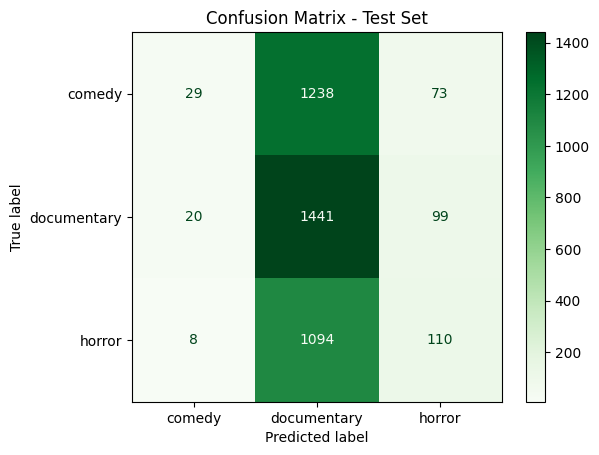

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test confusion matrix
test_cm = confusion_matrix(y_test, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=genre_label_encoder.classes_)
test_disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Test Set")
plt.show()
